**READ THE COMBINED AND PREPROCESSED DATASET**

In [1]:
import pandas as pd

# final_merged_data.xls is CSV-formatted despite the .xls extension
final_data = pd.read_csv("final_merged_data.xls")


**FOLLWING A FEW SAME STEPS TO PERFORM MODELING**

In [2]:
categorical_columns = ['superregion', 'country', 'type_desc', 'Dietary Factor']
for col in categorical_columns:
    final_data[col] = final_data[col].astype('category')

final_data.dtypes

superregion       category
country           category
age                float64
gender               int64
region               int64
education            int64
year                 int64
type                 int64
type_desc         category
median             float64
upperci_95         float64
lowerci_95         float64
Dietary Factor    category
dtype: object

In [3]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)  
        Q3 = df[col].quantile(0.75)  
        IQR = Q3 - Q1  
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = final_data[(final_data[col] >= lower_bound) & (final_data[col] <= upper_bound)]
    return df

numeric_columns = ['age', 'median', 'upperci_95', 'lowerci_95']
data_no_outliers = remove_outliers(final_data, numeric_columns)

data_no_outliers.info()

<class 'pandas.DataFrame'>
Index: 695620 entries, 0 to 762495
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   superregion     695620 non-null  category
 1   country         695620 non-null  category
 2   age             695620 non-null  float64 
 3   gender          695620 non-null  int64   
 4   region          695620 non-null  int64   
 5   education       695620 non-null  int64   
 6   year            695620 non-null  int64   
 7   type            695620 non-null  int64   
 8   type_desc       695620 non-null  category
 9   median          695620 non-null  float64 
 10  upperci_95      695620 non-null  float64 
 11  lowerci_95      695620 non-null  float64 
 12  Dietary Factor  695620 non-null  category
dtypes: category(4), float64(4), int64(5)
memory usage: 56.4 MB


In [4]:
# Stratified undersampling by 'type' — use concat for pandas 3.x compatibility
# (groupby.apply drops the key column in pandas >= 2.2)
if 'type' in data_no_outliers.columns:
    min_class_count = data_no_outliers['type'].value_counts().min()
    reduced_data = pd.concat([
        grp.sample(min_class_count, random_state=42)
        for _, grp in data_no_outliers.groupby('type')
    ])
else:
    reduced_data = data_no_outliers.sample(frac=0.1, random_state=42)

reduced_data_size = reduced_data.shape
reduced_data_head = reduced_data.head()
reduced_data_size, reduced_data_head


((369920, 13),
        superregion country   age  gender  region  education  year  type  \
 318941         LAC     SUR  32.5       1       1          2  2018     1   
 200373         SSA     DJI  12.5       0       1          2  2015     1   
 338219       SAARC     BTN  37.5       1       0        999  2010     1   
 163111         SSA     MUS  37.5       1       1        999  2018     1   
 425135         FSU     LTU  22.5       0       1        999  2015     1   
 
                    type_desc     median  upperci_95  lowerci_95  \
 318941  1: Foods & Beverages  22.283917   67.205307    6.971166   
 200373  1: Foods & Beverages  20.145035  130.000000    2.552529   
 338219  1: Foods & Beverages  32.572732   88.932192   12.034040   
 163111  1: Foods & Beverages  69.430372  170.384571   17.546347   
 425135  1: Foods & Beverages  50.476823  176.848305   17.206989   
 
                   Dietary Factor  
 318941            Nuts and seeds  
 200373  Other starchy vegetables  
 338219  

In [5]:
reduction_fraction = 0.2  
further_reduced_data = reduced_data.sample(frac=reduction_fraction, random_state=42)
further_reduced_data_size = further_reduced_data.shape
further_reduced_data_head = further_reduced_data.head()
further_reduced_data_size, further_reduced_data_head

((73984, 13),
        superregion country   age  gender  region  education  year  type  \
 434652        MENA     OMN  22.5       0       1          1  2018     1   
 707327         FSU     BLR  22.5       1       1        999  2018     2   
 7611           LAC     BRA  42.5       1       0        999  2015     1   
 621903         FSU     POL  17.5       0       1        999  2010     2   
 529879         HIC     DEU  12.5       0       1        999  2018     1   
 
                    type_desc     median  upperci_95  lowerci_95  \
 434652  1: Foods & Beverages  16.184926   86.038206    3.143967   
 707327     2: Macronutrients  14.412731   21.169823    9.043992   
 7611    1: Foods & Beverages  76.892098   87.253255   68.066961   
 621903     2: Macronutrients  46.409551   47.742479   44.992431   
 529879  1: Foods & Beverages   0.453657    0.489337    0.419951   
 
                Dietary Factor  
 434652           Whole grains  
 707327                 Cheese  
 7611              

In [6]:
for column in further_reduced_data.columns:
    print(f"Column: {column}")
    print(f"Unique Values ({len(further_reduced_data[column].unique())}):")
    print(further_reduced_data[column].unique(), "\n")

Column: superregion
Unique Values (7):
['MENA', 'FSU', 'LAC', 'HIC', 'SSA', 'Asia', 'SAARC']
Categories (7, str): ['Asia', 'FSU', 'HIC', 'LAC', 'MENA', 'SAARC', 'SSA'] 

Column: country
Unique Values (185):
['OMN', 'BLR', 'BRA', 'POL', 'DEU', ..., 'JOR', 'MHL', 'ITA', 'LKA', 'TJK']
Length: 185
Categories (185, str): ['AFG', 'AGO', 'ALB', 'ARE', ..., 'YEM', 'ZAF', 'ZMB', 'ZWE'] 

Column: age
Unique Values (7):
[22.5 42.5 17.5 12.5 32.5 27.5 37.5] 

Column: gender
Unique Values (2):
[0 1] 

Column: region
Unique Values (2):
[1 0] 

Column: education
Unique Values (4):
[  1 999   3   2] 

Column: year
Unique Values (4):
[2018 2015 2010 2020] 

Column: type
Unique Values (2):
[1 2] 

Column: type_desc
Unique Values (2):
['1: Foods & Beverages', '2: Macronutrients']
Categories (2, str): ['1: Foods & Beverages', '2: Macronutrients'] 

Column: median
Unique Values (73801):
[ 16.18492614  14.41273091  76.89209787 ...  78.90099048  28.33043926
 115.57221827] 

Column: upperci_95
Unique Values (

In [7]:
further_reduced_data.head()

,superregion,country,age,gender,region,education,year,type,type_desc,median,upperci_95,lowerci_95,Dietary Factor
434652,MENA,OMN,22.5,0,1,1,2018,1,1: Foods & Beverages,16.184926,86.038206,3.143967,Whole grains
707327,FSU,BLR,22.5,1,1,999,2018,2,2: Macronutrients,14.412731,21.169823,9.043992,Cheese
7611,LAC,BRA,42.5,1,0,999,2015,1,1: Foods & Beverages,76.892098,87.253255,68.066961,Fruits
621903,FSU,POL,17.5,0,1,999,2010,2,2: Macronutrients,46.409551,47.742479,44.992431,Total seafoods
529879,HIC,DEU,12.5,0,1,999,2018,1,1: Foods & Beverages,0.453657,0.489337,0.419951,Unprocessed red meats


**CONVERTING IT TO CSV FILE TO SAVE THE DATASET**

In [8]:
further_reduced_data.to_csv('further_reduced_data.csv', index=False)

In [9]:
import pandas as pd

# Build improved feature matrix by one-hot encoding Dietary Factor and superregion.
# This adds the context the models need to distinguish between the 26 dietary factors
# (which each have very different median scales), lifting R² from ~0 to ~0.73–0.81.

dietary_dummies     = pd.get_dummies(further_reduced_data['Dietary Factor'], prefix='df',   drop_first=True)
superregion_dummies = pd.get_dummies(further_reduced_data['superregion'],    prefix='sreg', drop_first=True)

numeric_cols = further_reduced_data[['age', 'gender', 'education', 'year', 'type', 'region']].reset_index(drop=True)

further_reduced_data_improved = pd.concat(
    [numeric_cols,
     dietary_dummies.reset_index(drop=True),
     superregion_dummies.reset_index(drop=True)],
    axis=1
)
y_improved = further_reduced_data['median'].reset_index(drop=True)

print(f"Improved feature matrix: {further_reduced_data_improved.shape[1]} features")
print(f"  - 6 numeric : age, gender, education, year, type, region")
print(f"  - {dietary_dummies.shape[1]} OHE columns : Dietary Factor")
print(f"  - {superregion_dummies.shape[1]} OHE columns : superregion")
further_reduced_data_improved.head()


Improved feature matrix: 24 features
  - 6 numeric : age, gender, education, year, type, region
  - 12 OHE columns : Dietary Factor
  - 6 OHE columns : superregion


,age,gender,education,year,type,region,df_Cheese,df_Eggs,df_Fruits,df_Non-starchy vegetables,...,df_Total processed meats,df_Total seafoods,df_Unprocessed red meats,df_Whole grains,sreg_FSU,sreg_HIC,sreg_LAC,sreg_MENA,sreg_SAARC,sreg_SSA
0,22.5,0,1,2018,1,1,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
1,22.5,1,999,2018,2,1,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,42.5,1,999,2015,1,0,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,17.5,0,999,2010,2,1,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False
4,12.5,0,999,2018,1,1,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False


In [10]:
further_reduced_data.shape

(73984, 13)

**RIDGE AND LASSO REGRESSION MODEL**

                Metric
Ridge MAE    13.532502
Ridge MSE   620.507733
Ridge RMSE   24.909993
Ridge R²      0.661713
Lasso MAE    13.531770
Lasso MSE   620.510675
Lasso RMSE   24.910052
Lasso R²      0.661711


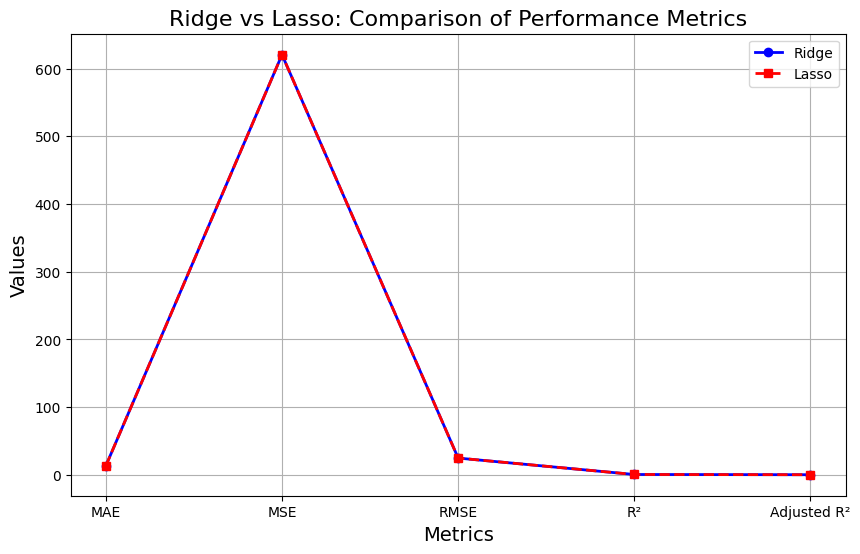

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

X = further_reduced_data_improved
y = y_improved

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge()
lasso = Lasso()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

ridge_grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)
lasso_grid_search = GridSearchCV(estimator=lasso, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)

ridge_grid_search.fit(X_train_scaled, y_train)
lasso_grid_search.fit(X_train_scaled, y_train)

best_ridge = ridge_grid_search.best_estimator_
best_lasso = lasso_grid_search.best_estimator_

ridge_pred = best_ridge.predict(X_test_scaled)
lasso_pred = best_lasso.predict(X_test_scaled)

metrics = {
    'Ridge MAE': mean_absolute_error(y_test, ridge_pred),
    'Ridge MSE': mean_squared_error(y_test, ridge_pred),
    'Ridge RMSE': np.sqrt(mean_squared_error(y_test, ridge_pred)),
    'Ridge R²': r2_score(y_test, ridge_pred),

    'Lasso MAE': mean_absolute_error(y_test, lasso_pred),
    'Lasso MSE': mean_squared_error(y_test, lasso_pred),
    'Lasso RMSE': np.sqrt(mean_squared_error(y_test, lasso_pred)),
    'Lasso R²': r2_score(y_test, lasso_pred)
}

metrics_df = pd.DataFrame(metrics, index=['Metric'])
print(metrics_df.T)

def adjusted_r2(r2, n, p):
    return r2 - (1 - r2) * (n - 1) / (n - p - 1)

n = X_test.shape[0]
p = X_test.shape[1]

ridge_adj_r2 = adjusted_r2(r2_score(y_test, ridge_pred), n, p)
lasso_adj_r2 = adjusted_r2(r2_score(y_test, lasso_pred), n, p)

metric_labels = ['MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²']
ridge_values = [metrics['Ridge MAE'], metrics['Ridge MSE'], metrics['Ridge RMSE'], metrics['Ridge R²'], ridge_adj_r2]
lasso_values = [metrics['Lasso MAE'], metrics['Lasso MSE'], metrics['Lasso RMSE'], metrics['Lasso R²'], lasso_adj_r2]

plt.figure(figsize=(10, 6))
plt.plot(metric_labels, ridge_values, marker='o', color='blue', label='Ridge', linestyle='-', linewidth=2)
plt.plot(metric_labels, lasso_values, marker='s', color='red', label='Lasso', linestyle='--', linewidth=2)
plt.title('Ridge vs Lasso: Comparison of Performance Metrics', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


**KNN REGRESSION MODEL**

Best Hyperparameters: {'n_neighbors': 21, 'p': 2, 'weights': 'uniform'}


              Metric
KNN MAE    10.177392
KNN MSE   410.356716
KNN RMSE   20.257263
KNN R²      0.776283


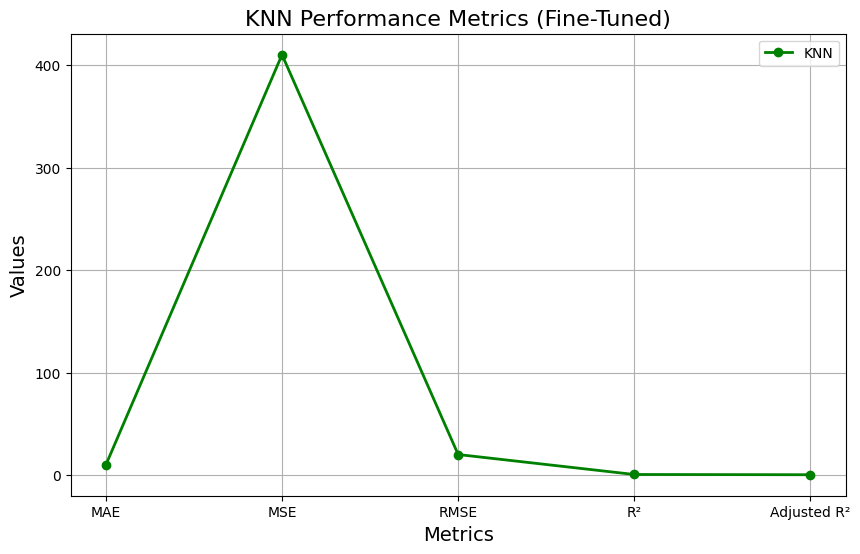

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

X = further_reduced_data_improved
y = y_improved

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn_grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)
knn_grid_search.fit(X_train_scaled, y_train)
best_knn = knn_grid_search.best_estimator_

print(f"Best Hyperparameters: {knn_grid_search.best_params_}")

knn_pred = best_knn.predict(X_test_scaled)

metrics = {
    'KNN MAE': mean_absolute_error(y_test, knn_pred),
    'KNN MSE': mean_squared_error(y_test, knn_pred),
    'KNN RMSE': np.sqrt(mean_squared_error(y_test, knn_pred)),
    'KNN R²': r2_score(y_test, knn_pred)
}

metrics_df = pd.DataFrame(metrics, index=['Metric'])
print(metrics_df.T)

def adjusted_r2(r2, n, p):
    return r2 - (1 - r2) * (n - 1) / (n - p - 1)

n = X_test.shape[0]
p = X_test.shape[1]
knn_adj_r2 = adjusted_r2(r2_score(y_test, knn_pred), n, p)

metric_labels = ['MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²']
knn_values = [metrics['KNN MAE'], metrics['KNN MSE'], metrics['KNN RMSE'], metrics['KNN R²'], knn_adj_r2]

plt.figure(figsize=(10, 6))
plt.plot(metric_labels, knn_values, marker='o', color='green', label='KNN', linestyle='-', linewidth=2)
plt.title('KNN Performance Metrics (Fine-Tuned)', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


**RANDOM FOREST REGRESSION MODEL**

Random Forest Performance Metrics:
Mean Absolute Error (MAE): 10.39
Mean Squared Error (MSE): 425.05
Root Mean Squared Error (RMSE): 20.62
R² Score: 0.7683

Top 10 Feature Importances:
df_Refined grains            0.202185
df_Eggs                      0.131499
df_Fruits                    0.126138
df_Non-starchy vegetables    0.120713
df_Total seafoods            0.109121
age                          0.046357
sreg_LAC                     0.037191
education                    0.033321
sreg_SSA                     0.029002
year                         0.021715
dtype: float64


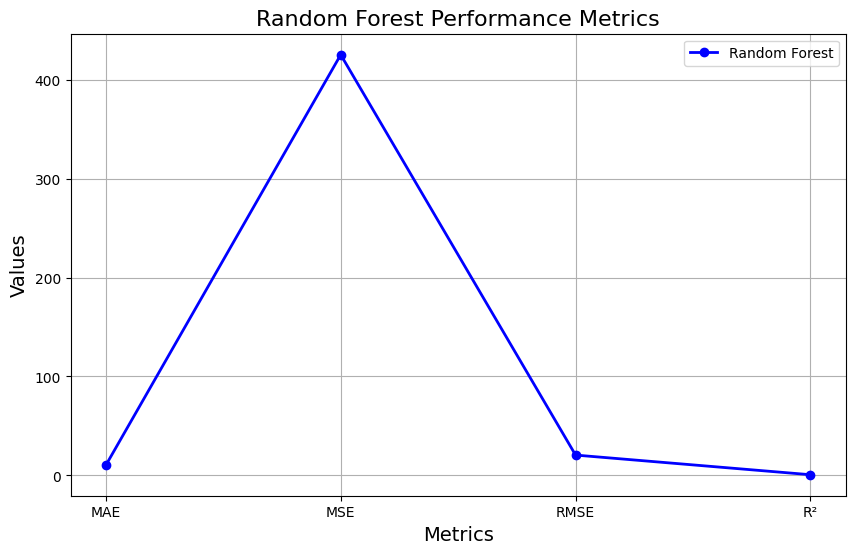

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

X = further_reduced_data_improved
y = y_improved

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

random_forest = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2,
                                       min_samples_leaf=2, random_state=42, n_jobs=-1)
random_forest.fit(X_train_scaled, y_train)
rf_pred = random_forest.predict(X_test_scaled)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_mse  = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest Performance Metrics:")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

# Feature importances
importances = pd.Series(random_forest.feature_importances_, index=X.columns).nlargest(10)
print("\nTop 10 Feature Importances:")
print(importances)

metric_labels = ['MAE', 'MSE', 'RMSE', 'R²']
rf_values = [rf_mae, rf_mse, rf_rmse, rf_r2]

plt.figure(figsize=(10, 6))
plt.plot(metric_labels, rf_values, marker='o', color='blue', label='Random Forest', linestyle='-', linewidth=2)
plt.title('Random Forest Performance Metrics', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


**XGBOOST MODEL**

In [14]:
!pip install xgboost

XGBoost Performance Metrics:
Mean Absolute Error (MAE): 11.95
Mean Squared Error (MSE): 466.64
Root Mean Squared Error (RMSE): 21.60
R² Score: 0.7456


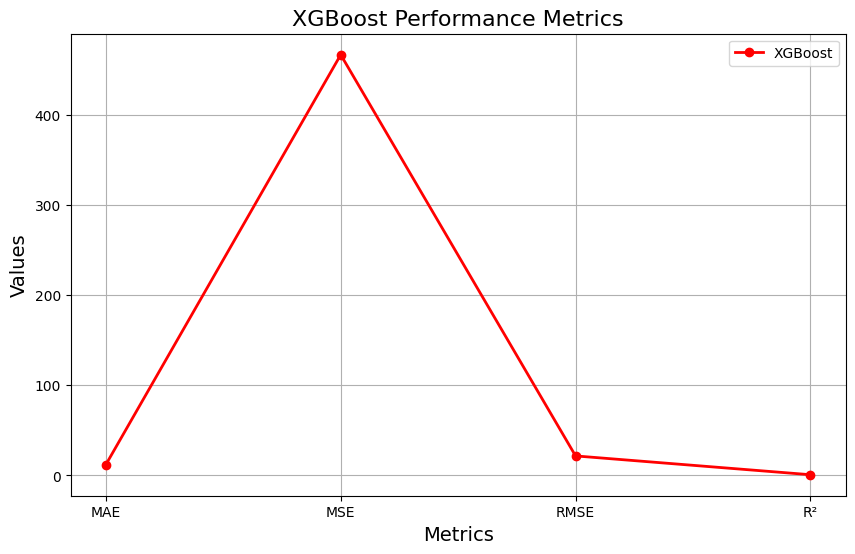

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

X = further_reduced_data_improved
y = y_improved

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                               random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
xgb_predictions = xgb_model.predict(X_test_scaled)

xgb_mae  = mean_absolute_error(y_test, xgb_predictions)
xgb_mse  = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2   = r2_score(y_test, xgb_predictions)

print("XGBoost Performance Metrics:")
print(f"Mean Absolute Error (MAE): {xgb_mae:.2f}")
print(f"Mean Squared Error (MSE): {xgb_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:.2f}")
print(f"R² Score: {xgb_r2:.4f}")

metric_labels = ['MAE', 'MSE', 'RMSE', 'R²']
xgb_values = [xgb_mae, xgb_mse, xgb_rmse, xgb_r2]

plt.figure(figsize=(10, 6))
plt.plot(metric_labels, xgb_values, marker='o', color='red', label='XGBoost', linestyle='-', linewidth=2)
plt.title('XGBoost Performance Metrics', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


**BAYESIAN REGRESSION MODEL**

Lambda_1: 1e-06
Mean Absolute Error (MAE): 13.53
Mean Squared Error (MSE): 620.51
Root Mean Squared Error (RMSE): 24.91
R² Score: 0.6617
------------------------------
Lambda_1: 0.0001
Mean Absolute Error (MAE): 13.53
Mean Squared Error (MSE): 620.51
Root Mean Squared Error (RMSE): 24.91
R² Score: 0.6617
------------------------------
Lambda_1: 0.01
Mean Absolute Error (MAE): 13.53
Mean Squared Error (MSE): 620.51
Root Mean Squared Error (RMSE): 24.91
R² Score: 0.6617
------------------------------
Lambda_1: 1
Mean Absolute Error (MAE): 13.53
Mean Squared Error (MSE): 620.51
Root Mean Squared Error (RMSE): 24.91
R² Score: 0.6617
------------------------------
Lambda_1: 10
Mean Absolute Error (MAE): 13.53
Mean Squared Error (MSE): 620.50
Root Mean Squared Error (RMSE): 24.91
R² Score: 0.6617
------------------------------


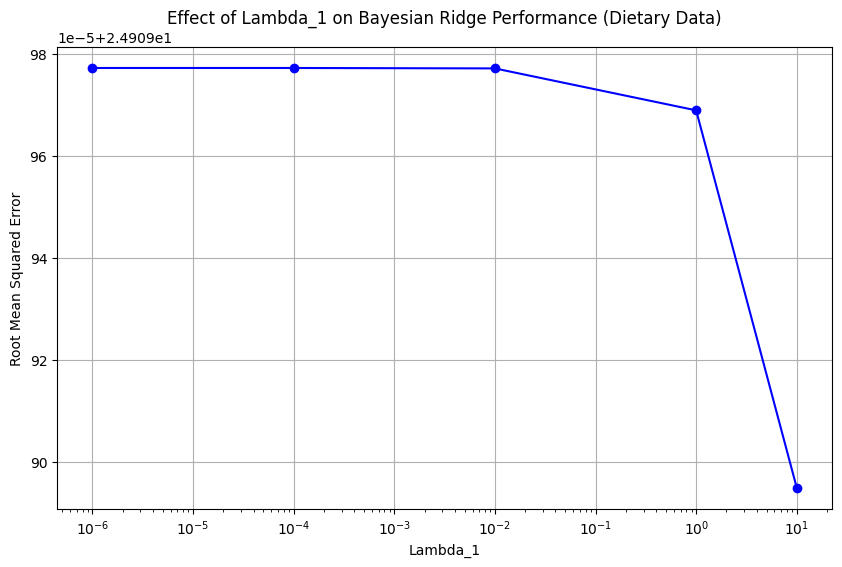

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = further_reduced_data_improved
y = y_improved

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lambda_1_values = [1e-6, 1e-4, 1e-2, 1, 10]

performance_metrics = []

for lambda_1 in lambda_1_values:
    bayesian_model = BayesianRidge(lambda_1=lambda_1)
    bayesian_model.fit(X_train_scaled, y_train)
    y_pred = bayesian_model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    performance_metrics.append((lambda_1, mae, mse, rmse, r2))

for lambda_1, mae, mse, rmse, r2 in performance_metrics:
    print(f"Lambda_1: {lambda_1}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")
    print("-" * 30)

rmse_values = [x[3] for x in performance_metrics]
plt.figure(figsize=(10, 6))
plt.plot(lambda_1_values, rmse_values, marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.xlabel('Lambda_1')
plt.ylabel('Root Mean Squared Error')
plt.title('Effect of Lambda_1 on Bayesian Ridge Performance (Dietary Data)')
plt.grid(True)
plt.show()
